##diabetes(당뇨병) 데이터셋을 활용한 예제 (결과치가 안좋은 사례)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
diabetes = pd.read_csv('./dataset/diabetes.csv')

In [ ]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# 특성(X)과 타겟(y) 분리
X = diabetes.drop('Outcome', axis=1)  # Outcome 열을 제외한 모든 특성
y = diabetes['Outcome']  # 타겟 변수

In [ ]:
# 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 선형회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 테스트 세트에 대한 예측
y_pred = model.predict(X_test)

In [ ]:
# 모델 성능 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
# 결과 출력
print('모델 성능 평가 결과:')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

모델 성능 평가 결과:
MSE: 0.1710
RMSE: 0.4136
R2 Score: 0.2550


In [ ]:
# 각 특성의 계수(가중치) 출력
feature_coefficients = pd.DataFrame({
    '특성': X.columns,
    '계수': model.coef_
})
print('\n특성별 가중치:')
print(feature_coefficients)


특성별 가중치:
                         특성        계수
0               Pregnancies  0.010468
1                   Glucose  0.005634
2             BloodPressure -0.002281
3             SkinThickness  0.000532
4                   Insulin -0.000278
5                       BMI  0.015039
6  DiabetesPedigreeFunction  0.111263
7                       Age  0.006460


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/

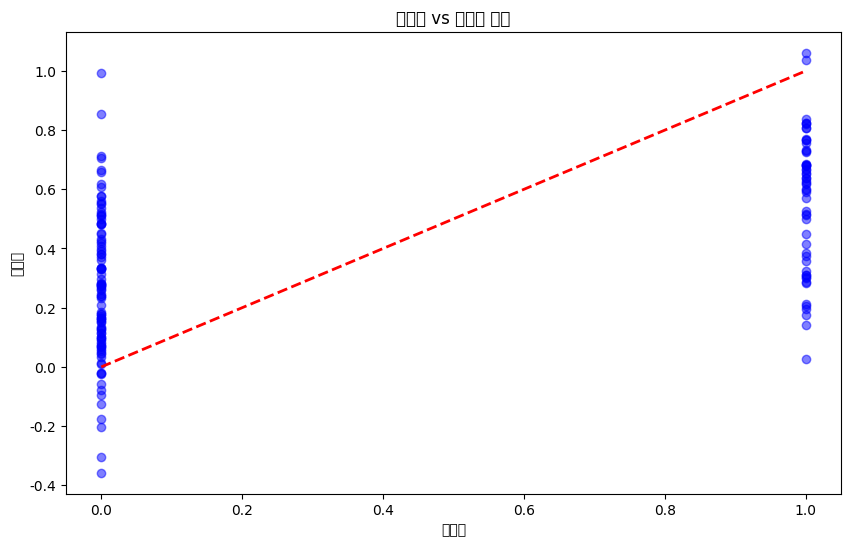

In [ ]:
# 실제값과 예측값 비교 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('실제값 vs 예측값 비교')
plt.show()

In [ ]:
# 예시: 첫 번째 테스트 데이터에 대한 예측
sample_data = X_test.iloc[0:1]
prediction = model.predict(sample_data)
print('\n새로운 데이터 예측 결과:')
print(f'예측값: {prediction[0]:.4f}')
print('실제 데이터:', sample_data.values[0])


새로운 데이터 예측 결과:
예측값: 0.3355
실제 데이터: [  6.    98.    58.    33.   190.    34.     0.43  43.  ]
